# Fitting DMD Models of Many Flavors, and SINDy models to Simulated Circuit Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pysindy as ps
from pydmd import DMD
from pydmd import DMDc
from pydmd import FbDMD
from pydmd import OptDMD
from scipy.io import loadmat,savemat
from scipy.signal import StateSpace, lsim, dlsim, cont2discrete,butter,filtfilt,dimpulse,impulse,dlti
import pickle 
import sys
import functions
from functions.compare_operators import compare_operators
from functions.make_graph import make_graph
import importlib


In [2]:
filename = 'C:/Users/ducks/Plasma-Shit/Python_Stuff/data/continuous_vacuum_ss_model' #Vacuum state space model
with open(filename,'rb') as file:
    sysc = pickle.load(file)
    print(f'object successfully saved to {filename}')
A = sysc.A #A, B, C, and D matrix from the continuous time vacuum model
B = sysc.B
C = sysc.C
D = sysc.D

SampleTime = 1e-6
sysd = cont2discrete((A,B,C,D),SampleTime,'zoh') #discrete time version of the vacuum system

#A,B,C,D discrete time versions

A_d = sysd[0]
B_d = sysd[1]
C_d = sysd[2]
D_d = sysd[3]

time = np.linspace(0,.004,int(np.ceil(.004/SampleTime)))

#need to load in some voltage supply inputs for our system
Amplitude = 500
voltage = Amplitude*np.sin(2*np.pi*19000*time)
voltage_stack = np.vstack((voltage,voltage,voltage,voltage))


print(np.shape(time))

object successfully saved to C:/Users/ducks/Plasma-Shit/Python_Stuff/data/continuous_vacuum_ss_model
(4001,)


Text(0.5, 1.0, 'Eigenvalues of Discrete Time A matrix')

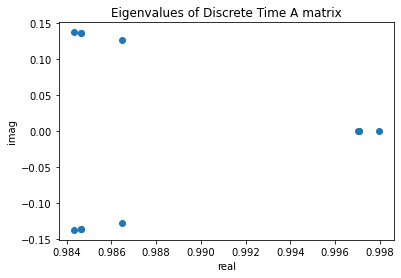

In [3]:
#check that eigevnalues are correct

eigs_discrete = np.linalg.eigvals(A_d)

plt.figure()
plt.scatter(eigs_discrete.real,eigs_discrete.imag)
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of Discrete Time A matrix')



# Let's simulate some data

In [4]:
xout_discrete = dlsim((sysd),voltage_stack.T,time)[-1]
print(np.shape(xout_discrete))


(4001, 12)


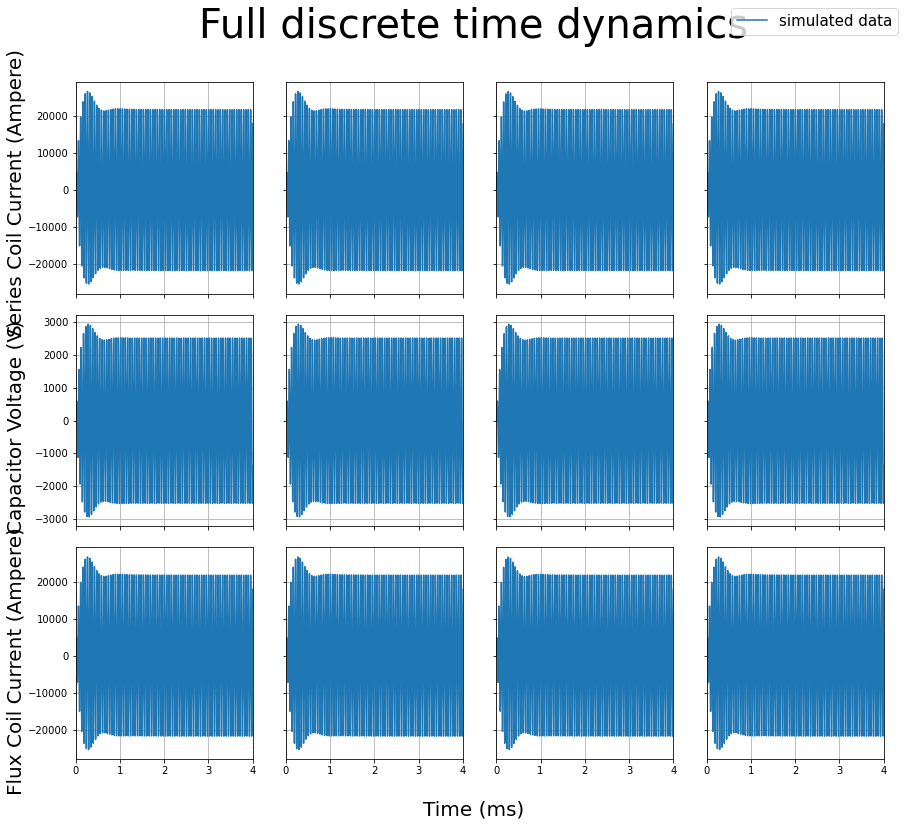

In [5]:
make_graph(data = [xout_discrete],title = 'Full discrete time dynamics',legend = ['simulated data'],impulse = False,time = time)

# Now we would like to train Various Models (DMD, SINDy), and track the residual as a function of time

In [6]:
#Because standard DMD methods don't play nice with actuation, we're going to train the DMD models on mock impulse response

impulse_input = np.zeros(np.shape(voltage_stack))

impulse_input[0,0] = 1

t,y,xout_discrete_impulse = dlsim(sysd,impulse_input.T,time) #impulse response

xout_discrete_impulse = xout_discrete_impulse.T

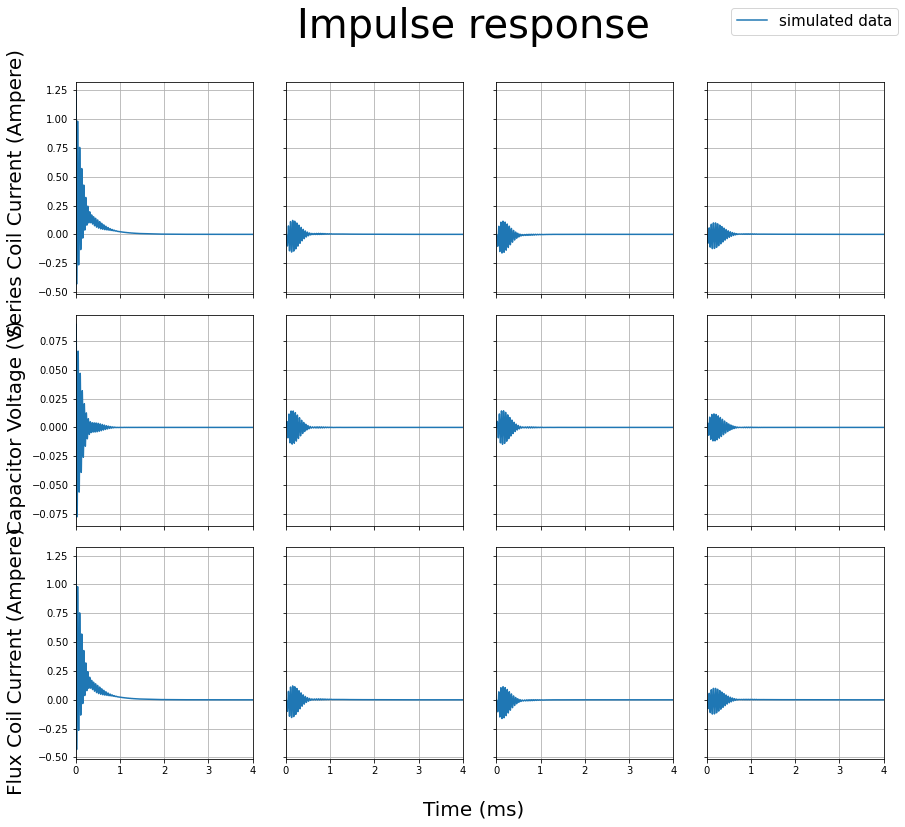

In [7]:
make_graph(data = [xout_discrete_impulse.T],title = 'Impulse response',legend = ['simulated data'],impulse = False,time = time)

In [8]:
 #full rank fit to the data

dmd = DMD(svd_rank = -1, tlsq_rank= 13, exact= False)

dmd.fit(xout_discrete_impulse)

A_tlsq_dmd = dmd.operator._Atilde


Text(0.5, 1.0, 'Eigenvalues of TLSQ-DMD compared to ground truth')

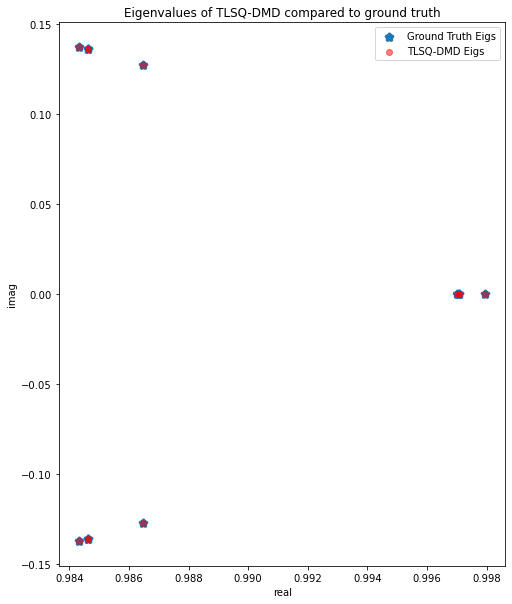

In [9]:
#check that eigevnalues are correct

eigs_discrete = np.linalg.eigvals(A_d)

plt.figure(figsize = (8,10))
plt.scatter(eigs_discrete.real,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(dmd.eigs.real,dmd.eigs.imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','TLSQ-DMD Eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of TLSQ-DMD compared to ground truth')



# DMD doesn't do so good. Let's try a different variant. How about FbDMD?

In [10]:
fbdmd = FbDMD(exact = False,svd_rank=-1,tlsq_rank=13)
fbdmd.fit(xout_discrete_impulse)

A_fbdmd = fbdmd.operator._Atilde

print(np.shape(A_fbdmd))

(12, 12)


Text(0.5, 1.0, 'Eigenvalues of True A matrix vs. FbDMD')

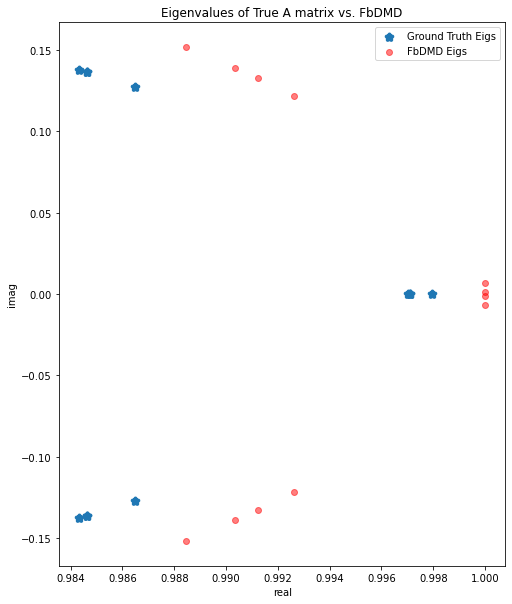

In [11]:
plt.figure(figsize = (8,10))
plt.scatter(eigs_discrete.real,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(fbdmd.eigs.real,fbdmd.eigs.imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','FbDMD Eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of True A matrix vs. FbDMD')



# Okay. We have computed TLSQ-DMD, FbDMD, and now for the classic: Exact DMD

In [12]:
A_DMD = xout_discrete_impulse[:,1::]@np.linalg.pinv(xout_discrete_impulse[:,:-1]) #exact DMD A matrix

print(np.shape(A_DMD))

(12, 12)


In [13]:
exact_dmd_eigs = np.linalg.eigvals(A_DMD)

Text(0.5, 1.0, 'Eigenvalues of True A matrix vs. Exact DMD')

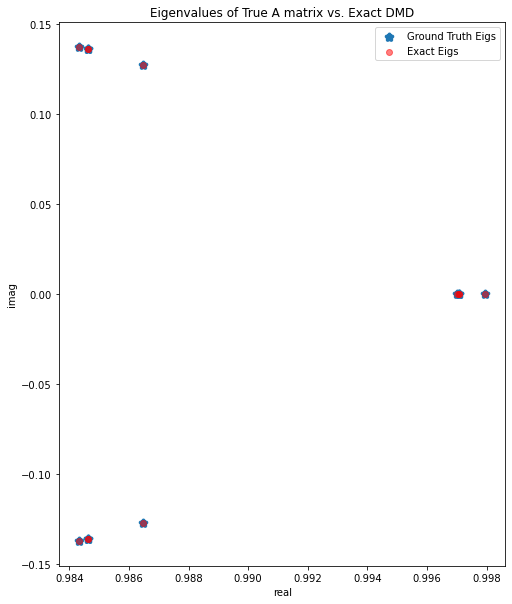

In [14]:
plt.figure(figsize = (8,10))
plt.scatter(eigs_discrete.real,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(exact_dmd_eigs.real,exact_dmd_eigs.imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','Exact Eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of True A matrix vs. Exact DMD')



# Takeaway: Exact DMD has the best reconstruction for Noiseless data. 

# Let's do a SINDy model as well


In [15]:
library = ps.PolynomialLibrary(degree=1,include_bias=False)
optimizer = ps.STLSQ(threshold=0)
model = ps.SINDy(feature_library = library,discrete_time=True,optimizer= optimizer)
model.fit(xout_discrete_impulse.T,time) 

A_SINDy = model.coefficients()

print(np.shape(A_SINDy))

(12, 12)


c:\Users\ducks\anaconda3\lib\site-packages\matplotlib\collections.py:206: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0.5, 1.0, 'Eigenvalues of True A matrix vs. SINDy')

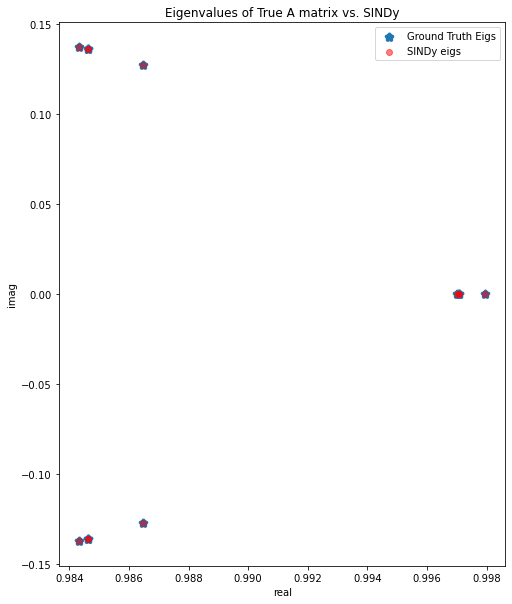

In [16]:
plt.figure(figsize = (8,10))
plt.scatter(eigs_discrete,eigs_discrete.imag,marker = "*",linewidths = 4)
plt.scatter(np.linalg.eigvals(A_SINDy).real,np.linalg.eigvals(A_SINDy).imag,alpha = .5,color = 'r')
plt.legend(['Ground Truth Eigs','SINDy eigs'])
plt.xlabel('real')
plt.ylabel('imag')
plt.title('Eigenvalues of True A matrix vs. SINDy')



## The final thing we would like to do here is track the rate at which the residual between the simulated DMD matrix diverges from the ground truth data. To do this, we will take the A matrix computed by each operator, and see how well it replicates the training data. We will also pair this matrix with a B matrix to see how well the system can handle a test case where a voltage waveform is given as an input

In [17]:
operator_list = [A_DMD,A_tlsq_dmd,A_SINDy]


trajectory_list = compare_operators(operator_list,(B_d,C_d,D_d),impulse_input,time,SampleTime)

data_list = trajectory_list + [xout_discrete_impulse.T]


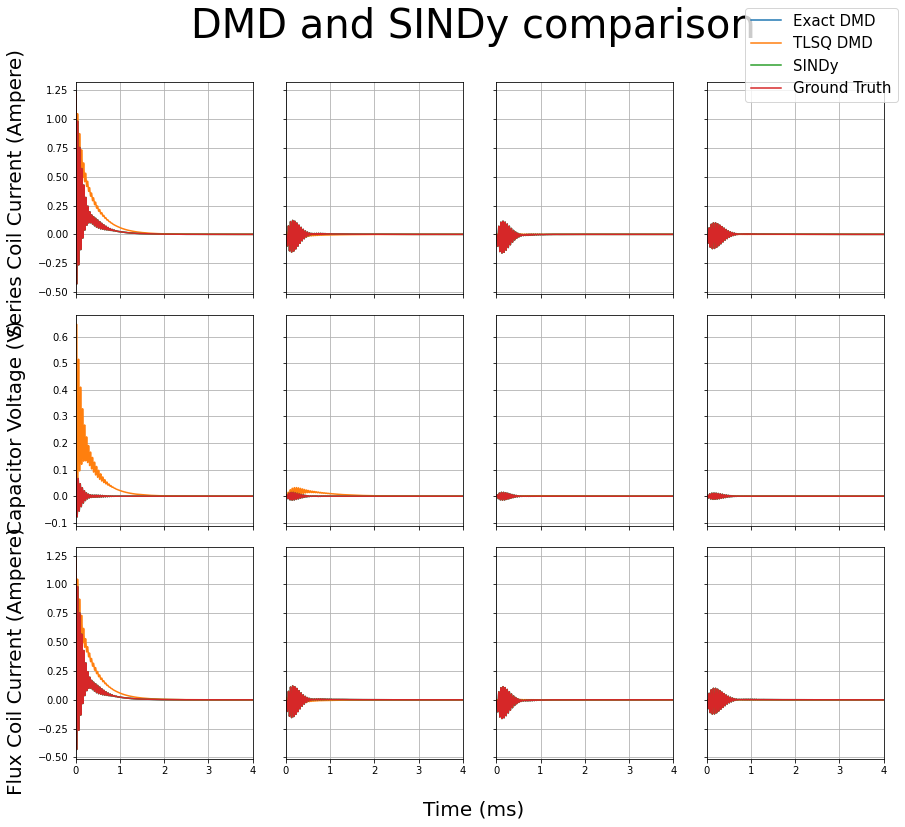

In [18]:
make_graph(data =data_list, title = 'DMD and SINDy comparison', legend = ['Exact DMD','TLSQ DMD','SINDy','Ground Truth'], impulse = False, time = time)

# The next thing is to plot the residual  as a function of time in each state

In [19]:
residual_list = []

for trajectory in data_list:
    residual = (trajectory - xout_discrete_impulse.T)**2 #LSTSQ error
    residual_list.append(residual)
print(len(residual_list))

4


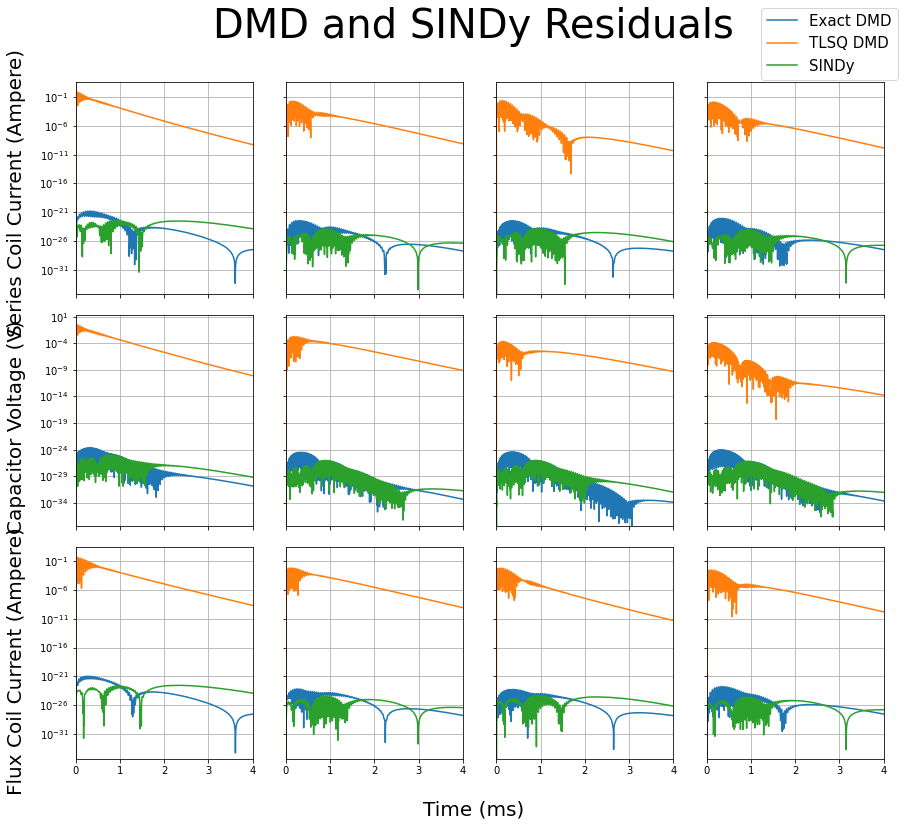

In [20]:
make_graph(data = residual_list, title = 'DMD and SINDy Residuals', legend = ['Exact DMD','TLSQ DMD','SINDy'], impulse = False, time = time,log_scale = True)

# Let's pickle these and start a new notebook where we can see how different models will behave in the presence of noise